In [5]:
import yaml
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
def parse(dat):
    assert dat['train']['num_nodes'] == dat['sys']['num_nodes']
    assert dat['train']['K'] == dat['sys']['K']
    assert dat['train']['b'] == dat['sys']['b']
    row = dat.copy()
    row['n'] = dat['sys']['num_nodes']
    row['K'] = dat['sys']['K']
    row['b'] = dat['sys']['b']
    row['train_gamma_C'] = dat['train']['gamma_C']
    row['train_beta_C'] = dat['train']['beta_C']
    
    row['min_gamma_C'] = dat['classifier']['fpr']
    row['min_beta_C'] = dat['classifier']['fnr']
    row['max_auc'] = dat['classifier']['auc']
    row['tau_log'] = dat['classifier']['tau']

    for alg in ['RDSGD', 'IOS', 'SCC', 'TriMean', 'CooMed']:
        row[f'{alg}_T3'] = dat['T3'][alg]['test_acc']
    
    del row['T0']
    del row['T3']
    del row['train']
    del row['sys']
    del row['classifier']
    del row['img']
    del row['C_img']
    
    return row

In [3]:
rows = []
with open("experiments.txt", 'r') as f:
    for line in f.read().splitlines():
        data = yaml.safe_load(line)
        rows.append(parse(data))
df = pd.DataFrame(rows)

In [4]:
df

,alpha_init,alpha_decay,atk_type,graph_type,graph_deg,reg_param,batch_sz,data_heterogeneity,proj_const,max_gamma_C,...,train_beta_C,min_gamma_C,min_beta_C,max_auc,tau_log,RDSGD_T3,IOS_T3,SCC_T3,TriMean_T3,CooMed_T3
0,0.5,0.1,label_flip,regular,3,0.2,100,0.1,2.4475,0.833333,...,0.5,0.0021,0.0095,0.9998,0.6876,0.8289,0.7655,0.7806,0.7789,0.7727
1,0.5,0.1,label_flip,regular,4,0.2,100,0.1,2.4475,0.468750,...,0.5,0.0000,0.0000,1.0000,0.9617,0.8344,0.8304,0.7564,0.7761,0.7738
2,0.5,0.1,label_flip,regular,6,0.2,100,0.5,1.9325,1.000000,...,0.5,0.2607,0.0100,0.9810,0.0787,0.8497,0.8341,0.4980,0.7634,0.7467


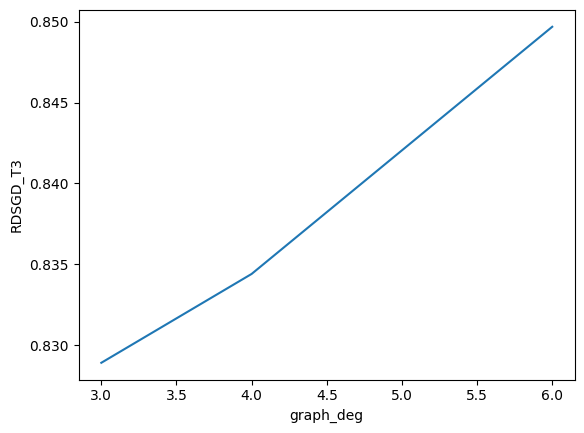

In [8]:
sns.lineplot(data=df, x='graph_deg', y='RDSGD_T3')
plt.show()